In [2]:
from notebook_utils import modify_sys_path, get_src_dir_path

modify_sys_path()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd

In [4]:
def rotate_point(point, angle):
    """Rotate two point by an angle.

    Parameters
    ----------
    point: 2d numpy array
        The coordinate to rotate.
    angle: float
        The angle of rotation of the point, in degrees.

    Returns
    -------
    2d numpy array
        Rotated point.
    """
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    rotated_point = rotation_matrix.dot(point)
    return rotated_point


def generate_spiral(samples, start, end, angle, noise):
    """Generate a spiral of points.

    Given a starting end, an end angle and a noise factor, generate a spiral of points along
    an arc.

    Parameters
    ----------
    samples: int
        Number of points to generate.
    start: float
        The starting angle of the spiral in degrees.
    end: float
        The end angle at which to rotate the points, in degrees.
    angle: float
        Angle of rotation in degrees.
    noise: float
        The noisyness of the points inside the spirals. Needs to be less than 1.
    """
    # Generate points from the square root of random data inside an uniform distribution on [0, 1).
    points = math.radians(start) + np.sqrt(np.random.rand(samples, 1)) * math.radians(end)

    # Apply a rotation to the points.
    rotated_x_axis = np.cos(points) * points + np.random.rand(samples, 1) * noise
    rotated_y_axis = np.sin(points) * points + np.random.rand(samples, 1) * noise

    # Stack the vectors inside a samples x 2 matrix.
    rotated_points = np.column_stack((rotated_x_axis, rotated_y_axis))
    return np.apply_along_axis(rotate_point, 1, rotated_points, math.radians(angle))


def main(arms: int, count: int, start: int, end: int, noise: float):

    # Create a list of the angles at which to rotate the arms.
    # Either we find the angles automatically by dividing by the number of arms
    # Or we just use the angle given by the user.
    classes = np.empty((0, 3))
    angles = [(360 / arms)* i for i in range(arms)]

    for i, angle in enumerate(angles):
        points = generate_spiral(count, start, end, angle, noise)
        classified_points = np.hstack((points, np.full((count, 1), i)))
        classes = np.concatenate((classes, classified_points))
        
        
    return classes

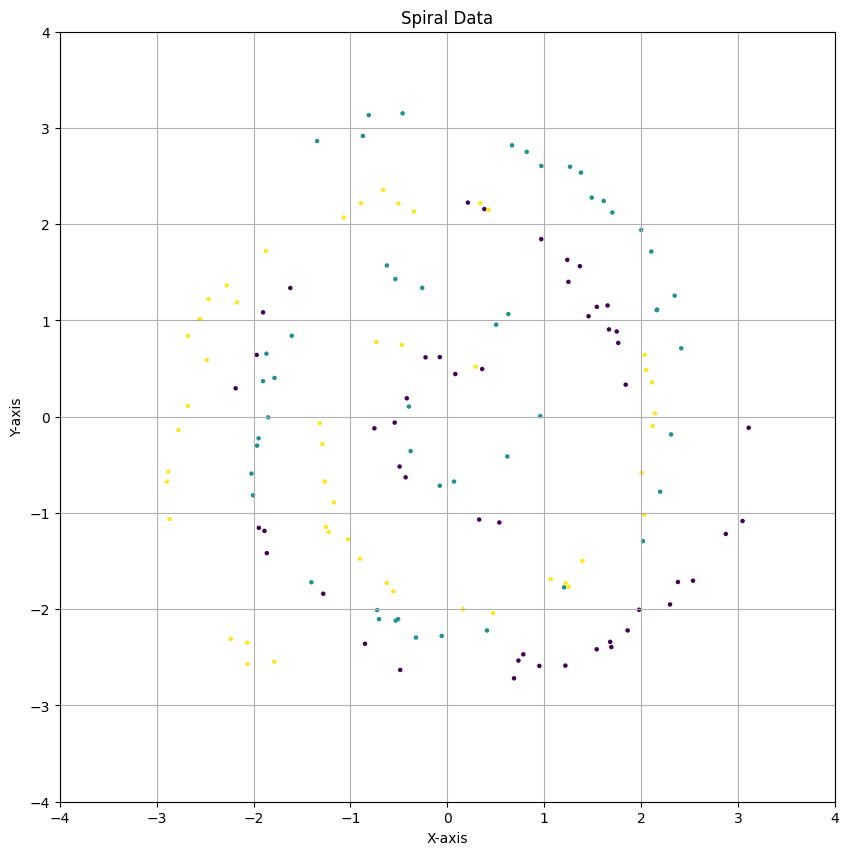

In [18]:
classes = main(arms=3, count=50, start=0, end=720, noise=1.2)
plt.figure(figsize=(10, 10))
plt.scatter(classes[:, 0]/4, classes[:, 1]/4, c=classes[:, 2], cmap='viridis', s=5)
plt.title('Spiral Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid()
plt.show()

In [27]:
# moons_data = pd.read_csv(get_src_dir_path() + '/datasets_toy_classification/moons_2/data.csv')

moons_data = pd.read_csv(get_src_dir_path() + '/results/moons_2/qwen14b/experiment_1/D_50_shot_5_z_5_random_10_perm.csv')

spirals_data = pd.read_csv(get_src_dir_path() + '/datasets_toy_classification/spirals/data.csv').sample(200)

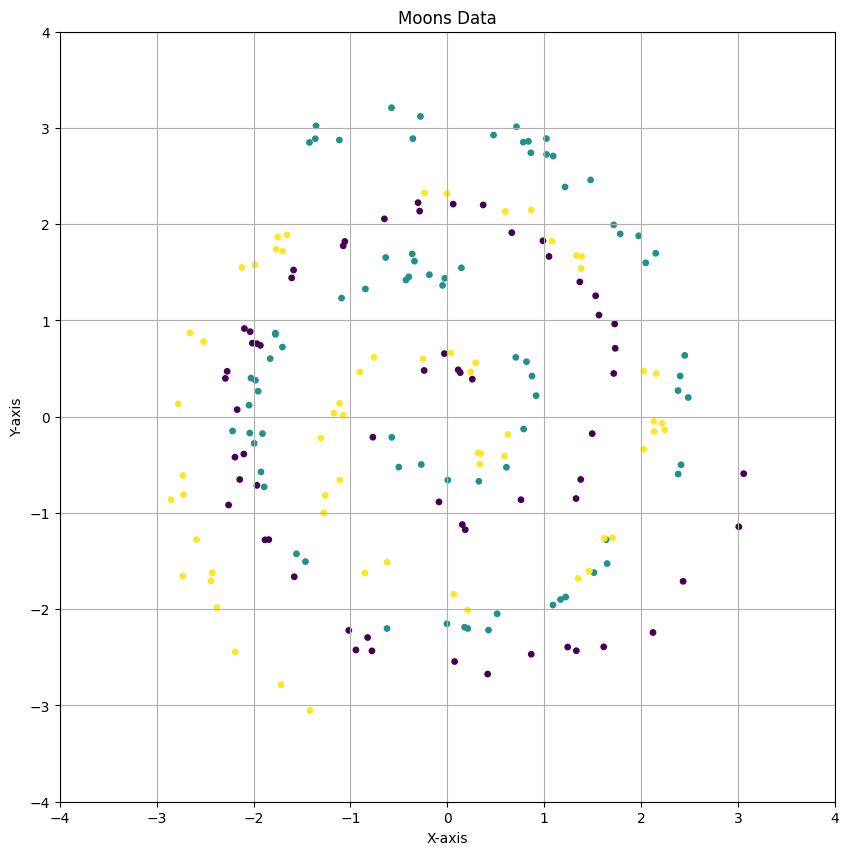

In [28]:
plt.figure(figsize=(10, 10))
plt.scatter(spirals_data['x1'], spirals_data['x2'], c=spirals_data['label'], cmap='viridis', s=15)
plt.title('Moons Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid()
plt.show()